# Bias Analysis

This notebook assesses potential bias in NovaCred's past loan approval decisions. The analysis focused in differences in protected features (gender and age), intersectional effects (age × gender), and possible proxy discrimination through features such as ZIP code.

Fairness is measured using loan approval rate comparisons, Disparate Impact (four-fifths rule), Demographic Parity Difference, and chi-square statistical significance tests. The aim is to evaluate  whether observed approval outcomes show systemic disparities.

## Table of Contents

## 1. Executive Summary

## 2. Methodology

## 3. Dataset Overview for Bias Analysis

### 3.1 Importing Necessary Libraries

In [39]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from fairlearn.metrics import demographic_parity_difference
from datetime import datetime


### 3.2 Dataset loading

In [2]:
df = pd.read_csv("../data/credit_applications_clean.csv")
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,22.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,31.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909,True,NaN,vacation,3.7,59000.0,34.0
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,70.0,0.35,0,True,NaN,NaN,4.3,34000.0,40.0
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15 00:00:00+00:00,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,14.0,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,24.0


### 3.3 Dataset Structure and Size

In [7]:
# Checking basic info and distributions
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               501 non-null    object 
 1   spending_behavior                 501 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          501 non-null    object 
 4   applicant_info.email              494 non-null    object 
 5   applicant_info.ssn                496 non-null    object 
 6   applicant_info.ip_address         496 non-null    object 
 7   applicant_info.gender             498 non-null    object 
 8   applicant_info.date_of_birth      496 non-null    object 
 9   applicant_info.zip_code           499 non-null    float64
 10  financials.annual_income          496 non-null    float64
 11  financials.credit_history_months  499 non-null    float64
 12  financia

,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.interest_rate,decision.approved_amount,age
count,499.000000,496.000000,499.000000,500.000000,501.000000,292.000000,292.000000,339.000000
mean,47735.408818,82732.727397,50.645291,0.242660,29520.489022,4.564726,47845.890411,38.952802
std,39521.627144,28123.590403,31.117029,0.115888,16781.166700,1.162866,18103.754530,11.161701
min,10001.000000,0.000000,0.000000,0.050000,-5000.000000,2.500000,15000.000000,21.000000
25%,10048.000000,63000.000000,28.000000,0.150000,17289.000000,3.500000,34000.000000,30.500000
50%,10098.000000,81500.000000,49.000000,0.230000,27397.000000,4.550000,48000.000000,37.000000
75%,90244.000000,101250.000000,72.000000,0.342500,38281.000000,5.600000,62250.000000,45.000000
max,90299.000000,171000.000000,133.000000,0.450000,88078.000000,6.500000,80000.000000,65.000000


### 3.4 Key variables for the analysis

The bias analysis focuses on the following key variables:

- **decision.loan_approved** — binary outcome indicating whether the loan was approved.
- **applicant_info.gender** — gender of the applicant.
- **applicant_info.date_of_birth / applicant_info_age** — used to derive age and age groups.
- **applicant_info.zip_code** — geographic attribute evaluated as a potential proxy variable.
- **financial variables** (income, credit history, debt-to-income) — used to understand potential structural differences across groups.

### 3.5 Missing Data Checks

In [8]:
df.isna().sum()

_id                                   0
spending_behavior                     0
processing_timestamp                439
applicant_info.full_name              0
applicant_info.email                  7
applicant_info.ssn                    5
applicant_info.ip_address             5
applicant_info.gender                 3
applicant_info.date_of_birth          5
applicant_info.zip_code               2
financials.annual_income              5
financials.credit_history_months      2
financials.debt_to_income             1
financials.savings_balance            0
decision.loan_approved                0
decision.rejection_reason           292
loan_purpose                        451
decision.interest_rate              209
decision.approved_amount            209
age                                 162
dtype: int64

## 4. Gender Disparity Analysis

### 4.1 Loan Approval Rates - Comparison

Overall approval rate: 58.28%


,Rejected,Approved,Total,Approval Rate (%)
applicant_info.gender,,,,
Female,124,127,251,50.60
Male,84,163,247,65.99


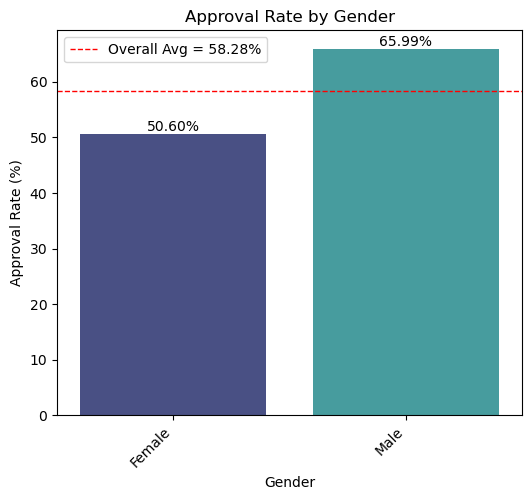

Difference in approval rates (Male − Female): 15.39 percentage points


In [44]:
# Calculate overall approval rate
overall_rate = df["decision.loan_approved"].mean()
overall_rate_percent = (overall_rate * 100).round(2).astype(str) + "%"

print("Overall approval rate:", overall_rate_percent)
# Approval summary by gender
gender_summary = pd.crosstab(
    df["applicant_info.gender"],
    df["decision.loan_approved"]
)

gender_summary.columns = ["Rejected", "Approved"]

# Add totals
gender_summary["Total"] = gender_summary["Rejected"] + gender_summary["Approved"]

# Add approval rate %
gender_summary["Approval Rate (%)"] = (
    gender_summary["Approved"] / gender_summary["Total"] * 100
).round(2)

display(gender_summary)

# Plotting 
plot_df = gender_summary.reset_index().rename(columns={"index": "applicant_info.gender"})

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=plot_df,
    x="applicant_info.gender",
    y="Approval Rate (%)",
    hue="applicant_info.gender",
    palette="mako",
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.axhline(
    overall_rate * 100,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall Avg = {overall_rate:.2%}"
)

plt.legend(loc="best")

plt.xticks(rotation=45, ha='right')
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Gender")
plt.show()


female_rate = gender_summary.loc["Female", "Approval Rate (%)"]
male_rate = gender_summary.loc["Male", "Approval Rate (%)"]

rate_diff = male_rate - female_rate

print(f"Difference in approval rates (Male − Female): {rate_diff:.2f} percentage points")

- The loan approval rate for male candidates is 65.99%, whilst the approval rate for female applicants is 50.60%, a gap in loan acceptance between gender groups.
- The dataset also shows a nearly equal distribution of applications by gender (251 females vs. 247 males), indicating that sample imbalance is unlikely to be the cause of the discrepancy.

### 4.2 Disparate Impact

In [31]:
# Compute DI (privileged group = male)
female_rate = gender_summary.loc["Female", "Approval Rate (%)"] / 100
male_rate = gender_summary.loc["Male", "Approval Rate (%)"] / 100

disparate_impact = female_rate / male_rate


print(f"Male approval rate: {male_rate:.2%}")
print(f"Female approval rate: {female_rate:.2%}")
print(f"Disparate Impact (%): {disparate_impact*100:.2f}%")


Male approval rate: 65.99%
Female approval rate: 50.60%
Disparate Impact (%): 76.68%


- A DI below 80% indicates a possible negative impact on the underprivileged group (in this case, female candidates) according to the four-fifths rule. If below this threshold, it means that approval rates for women are less than 80% of that for men.
- Loan approval rates fall short of the four-fifths criteria (76.68% is less than 80%). This offers evidence of possible gender-based disparities in the approval process.

### 4.3 Demographic Parity Difference

In [41]:
from fairlearn.metrics import demographic_parity_difference

df_dpd_gender = df[df["applicant_info.gender"].notna() & df["decision.loan_approved"].notna()].copy()
df_dpd_gender["loan_approved_int"]= df_dpd_gender["decision.loan_approved"].astype(int)

dpd_gender = demographic_parity_difference(
    y_true=df_dpd_gender["loan_approved_int"],
    y_pred=df_dpd_gender["loan_approved_int"],
    sensitive_features=df_dpd_gender["applicant_info.gender"]
)

print(f"Demographic Parity Difference: {dpd_gender*100:.2f}%")

Demographic Parity Difference: 15.39%


- The demographic parity difference is defined as the difference between the largest and the smallest group-level selection rate.
- A difference between the highest and lowest group-level selection rate up to 0.1 is often considered fair.
- The calculated DPD is 15.39% and this kind of discrepancy suggests that there may be a gender fairness concern.

### 4.4 Statistical Significance

In [43]:
# Creating contigency table 
table = pd.crosstab(df["applicant_info.gender"], df["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')




Contingency table:
decision.loan_approved  False  True 
applicant_info.gender               
Female                    124    127
Male                       84    163
Chi-squared Statistic: 11.5053
Degrees of Freedom: 1.0000
P-value: 0.0007
Dependent (reject H0)


- To determine if approval results were statistically related to gender and significant, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of gender.
- The results of the chi-square test of independence were:
    - χ²(1) = 11.50
    - p = 0.00069
- The findings suggest that gender and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(1) = 11.50, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.

## 5. Age Disparity Analysis

### 5.1 Loan Approval Rates - Comparison

Minimum age in dataset: 21.0
Maximum age in dataset: 65.0


,Rejected,Approved,Total,Approval Rate (%)
age_group,,,,
"(21.0, 25.0]",21,13,34,38.24
"(25.0, 30.0]",27,23,50,46.00
"(30.0, 40.0]",53,68,121,56.20
"(40.0, 50.0]",21,51,72,70.83
"(50.0, 60.0]",18,26,44,59.09
"(60.0, 65.0]",5,12,17,70.59


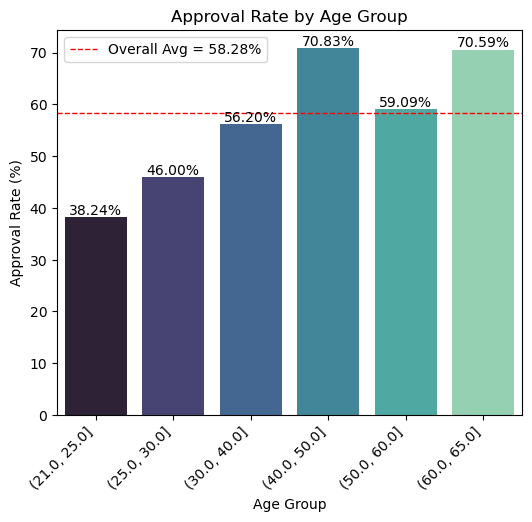

In [59]:
# minimum age
min_age = df["age"].min()
print(f"Minimum age in dataset: {min_age}")

# maximum age
max_age = df["age"].max()
print(f"Maximum age in dataset: {max_age}")

# Age buckets
df["age_group"] = pd.cut(df["age"], bins=[min_age, 25, 30, 40, 50, 60, max_age])

# Approval summary by age group
age_summary = pd.crosstab(
    df["age_group"],
    df["decision.loan_approved"]
)

age_summary.columns = ["Rejected", "Approved"]

# Add totals
age_summary["Total"] = age_summary["Rejected"] + age_summary["Approved"]

# Add approval rate %
age_summary["Approval Rate (%)"] = (
    age_summary["Approved"] / age_summary["Total"] * 100
).round(2)

display(age_summary)

# Plotting 
plot_df = age_summary.reset_index().rename(columns={"index": "age_group"})

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=plot_df,
    x="age_group",
    y="Approval Rate (%)",
    hue="age_group",
    palette="mako",
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.axhline(
    overall_rate * 100,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall Avg = {overall_rate:.2%}"
)

plt.legend(loc="best")

plt.xticks(rotation=45, ha='right')
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Age Group")
plt.show()


- The age distribution of applicants runs from 21 to 65 years old.
- Applicants aged 21-25 had the lowest approval rate of 38.24%, followed by those aged 25-30 with 46.00%. - Middle-aged candidates had higher approval rates, with 56.20% for the 30-40 group and 70.83% for the 40-50 group.
- Older applicants continue to have relatively high acceptance rates, with 59.09% for ages 50-60 and 70.59% for ages 60-65, despite the latter category having a lower sample size.Overall, the results imply that older applicants tend to have higher loan acceptance rates, whereas younger applicants suffer lower approval rates, indicating a possible age-related disparity in the approval process.

### 5.2 Disparate Impact

Because age has multiple categories/groups, we can't define a single “privileged group” as with gender. Instead, we calculated Disparate Impact by dividing the lowest approval rate by the highest approval rate. This way, we can measure how disadvantaged the worst-performing age group is relative to the best-performing one.

In [ ]:
# Compute approval rates by age group
age_rates = df.groupby("age_group", observed=True)["decision.loan_approved"].mean()

# Identify lowest and highest approval rates
min_rate = age_rates.min()
max_rate = age_rates.max()

# Identify least and most favored groups
least_favored_group = age_rates.idxmin()
most_favored_group = age_rates.idxmax()

# Compute Disparate Impact (least favored vs most favored)
disparate_impact_age = min_rate / max_rate

print(f"Least favored age group: {least_favored_group} ({min_rate:.2%})")
print(f"Most favored age group: {most_favored_group} ({max_rate:.2%})")

print(f"Age Disparate Impact (%): {disparate_impact_age*100:.2f}%")

Least favored age group: (21.0, 25.0] (38.24%)
Most favored age group: (40.0, 50.0] (70.83%)
Age Disparate Impact (%): 53.98%


- The least advantaged age group (21-25) receives approvals at only ~54% of the rate of the most advantaged group (40-50), which falls well below the four-fifths rule threshold and indicates potential age-based disparity.

### 5.3 Demographic Parity Difference

In [64]:
from fairlearn.metrics import demographic_parity_difference

df_dpd_age = df[df["age_group"].notna() & df["decision.loan_approved"].notna()].copy()
df_dpd_age["loan_approved_int"]= df_dpd_age["decision.loan_approved"].astype(int)

dpd_age = demographic_parity_difference(
    y_true=df_dpd_age["loan_approved_int"],
    y_pred=df_dpd_age["loan_approved_int"],
    sensitive_features=df_dpd_age["age_group"]
)

print(f"Age Demographic Parity Difference: {dpd_age*100:.2f}%")

Age Demographic Parity Difference: 32.60%


- The difference identified in the previous section is confirmed by the Demographic Parity Difference of 22.13%, indicating a notable (despite not too large) disparity between age groups.

### 5.4 Statistical Significance

In [66]:
# Creating contigency table 
table = pd.crosstab(df["age_group"], df["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')


Contingency table:
decision.loan_approved  False  True 
age_group                           
(21.0, 25.0]               21     13
(25.0, 30.0]               27     23
(30.0, 40.0]               53     68
(40.0, 50.0]               21     51
(50.0, 60.0]               18     26
(60.0, 65.0]                5     12
Chi-squared Statistic: 14.3720
Degrees of Freedom: 5.0000
P-value: 0.0134
Dependent (reject H0)



- To determine if approval results were statistically related to age and significant, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of age.
- The results of the chi-square test of independence were:
    - χ²(5) = 14.37
    - p = 0.0134
- The findings suggest that gender and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(5) = 14.37, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.

## 6. Age and Gender Interaction Analysis

### 6.1 Loan Approval Rates by Age and Gender

In [72]:
# Counts (N)
interaction_counts = pd.crosstab(df["age_group"], df["applicant_info.gender"])

# Approval rates (as %)
interaction_rates = pd.crosstab(
    df["age_group"],
    df["applicant_info.gender"],
    values=df["decision.loan_approved"],
    aggfunc="mean"
) * 100

counts = interaction_counts[["Female", "Male"]]
rates  = interaction_rates[["Female", "Male"]].round(2)

# Build table with counts, rates, and gaps
summary = pd.DataFrame(index=counts.index)

summary["N (Female)"] = counts["Female"]
summary["N (Male)"]   = counts["Male"]
summary["N (Total)"]  = counts.sum(axis=1)

summary["Approval % (Female)"] = rates["Female"]
summary["Approval % (Male)"]   = rates["Male"]

summary["Gap (Male − Female) (pp)"] = (summary["Approval % (Male)"] - summary["Approval % (Female)"]).round(2)
display(summary)

,N (Female),N (Male),N (Total),Approval % (Female),Approval % (Male),Gap (Male − Female) (pp)
age_group,,,,,,
"(21.0, 25.0]",20,14,34,35.00,42.86,7.86
"(25.0, 30.0]",28,22,50,35.71,59.09,23.38
"(30.0, 40.0]",56,65,121,53.57,58.46,4.89
"(40.0, 50.0]",33,39,72,63.64,76.92,13.28
"(50.0, 60.0]",24,19,43,50.00,68.42,18.42
"(60.0, 65.0]",9,8,17,66.67,75.00,8.33


- The intersectional analysis of age and gender shows that male applicants have higher loan approval rates than female applicants in every age group.
- The largest disparity occurs in the 25–30 age group, where approval rates are 59.09% for males and 35.71% for females, a gap of 23.38 percentage points.
- Similarly large gaps appear in the 50–60 age group (18.42 percentage points) and 40–50 age group (13.28 percentage points).
- In contrast, the 30–40 age group shows a smaller difference of 4.89 percentage points, suggesting more similar approval outcomes between genders in that range.

###  6.2 Gender Disparate Impact within Age Groups

In [73]:
import numpy as np

di_interaction = interaction_rates.copy()

# Disparate impact per age group (female/male)
di_interaction["DI (Female/Male)"] = (di_interaction["Female"] / di_interaction["Male"]).round(3)
di_interaction["Fails 80% Rule"] = di_interaction["DI (Female/Male)"] < 0.8

display(di_interaction)

applicant_info.gender,Female,Male,DI (Female/Male),Fails 80% Rule
age_group,,,,
"(21.0, 25.0]",35.000000,42.857143,0.817,False
"(25.0, 30.0]",35.714286,59.090909,0.604,True
"(30.0, 40.0]",53.571429,58.461538,0.916,False
"(40.0, 50.0]",63.636364,76.923077,0.827,False
"(50.0, 60.0]",50.000000,68.421053,0.731,True
"(60.0, 65.0]",66.666667,75.000000,0.889,False


- According to the four-fifths rule, a disparate impact ratio below 0.80 suggests potential adverse impact on the disadvantaged group. 
- The results indicate that this threshold is violated in two age groups: 25–30, where the DI is 0.604, and 50–60, where the DI is 0.731 (meaning female applicants in these groups receive approvals at substantially lower rates than males).
- In the remaining age groups, the DI ratios range from 0.817 to 0.916, which are above the 0.80 threshold but still indicate moderate disparities favoring male applicants.

### 6.3 Demographic Parity Difference

In [76]:
from fairlearn.metrics import demographic_parity_difference

# Create intersection group (age × gender)
df_intersection = df[
    df["applicant_info.gender"].isin(["Male", "Female"])
].dropna(subset=["age_group"]).copy()

df_intersection["age_gender_group"] = (
    df_intersection["age_group"].astype(str) + "_" +
    df_intersection["applicant_info.gender"].astype(str)
)

# Compute approval rate per intersection group
intersection_rates = (
    df_intersection
    .groupby("age_gender_group", observed=True)["decision.loan_approved"]
    .mean()
)

display((intersection_rates * 100).round(2))

# Identify extreme groups
most_advantaged = intersection_rates.idxmax()
least_advantaged = intersection_rates.idxmin()

most_rate = intersection_rates.max()
least_rate = intersection_rates.min()

print(f"Most advantaged group: {most_advantaged} ({most_rate*100:.2f}%)")
print(f"Least advantaged group: {least_advantaged} ({least_rate*100:.2f}%)")

# Compute Demographic Parity Difference across intersection groups
dpd_intersection = demographic_parity_difference(
    y_true=df_intersection["decision.loan_approved"],
    y_pred=df_intersection["decision.loan_approved"],
    sensitive_features=df_intersection["age_gender_group"]
)

print(f"Intersectional Demographic Parity Difference: {dpd_intersection*100:.2f}%")

age_gender_group
(21.0, 25.0]_Female    35.00
(21.0, 25.0]_Male      42.86
(25.0, 30.0]_Female    35.71
(25.0, 30.0]_Male      59.09
(30.0, 40.0]_Female    53.57
(30.0, 40.0]_Male      58.46
(40.0, 50.0]_Female    63.64
(40.0, 50.0]_Male      76.92
(50.0, 60.0]_Female    50.00
(50.0, 60.0]_Male      68.42
(60.0, 65.0]_Female    66.67
(60.0, 65.0]_Male      75.00
Name: decision.loan_approved, dtype: float64

Most advantaged group: (40.0, 50.0]_Male (76.92%)
Least advantaged group: (21.0, 25.0]_Female (35.00%)
Intersectional Demographic Parity Difference: 41.92%


- Male applicants aged 40-50 have the highest approval rate, at 76.92%, while female candidates aged 21-25 have the lowest approval rate, at 35.0%. - This substantial imbalance leads in an intersectional demographic parity difference of 41.92 percentage points.
- The findings indicate that younger female candidates had the lowest approval probability, whilst middle-aged male applicants have substantially higher acceptance rates.
- Overall, this intersectional pattern suggests that both age and gender impact approval outcomes, and the combined effect results in a greater gap than when each attribute is analyzed independently.

### 6.4 Statistical Significance

In [78]:
# Creating contigency table 
table = pd.crosstab(df_intersection["age_gender_group"], df_intersection["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"Degrees of Freedom: {dof:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')


Contingency table:
decision.loan_approved  False  True 
age_gender_group                    
(21.0, 25.0]_Female        13      7
(21.0, 25.0]_Male           8      6
(25.0, 30.0]_Female        18     10
(25.0, 30.0]_Male           9     13
(30.0, 40.0]_Female        26     30
(30.0, 40.0]_Male          27     38
(40.0, 50.0]_Female        12     21
(40.0, 50.0]_Male           9     30
(50.0, 60.0]_Female        12     12
(50.0, 60.0]_Male           6     13
(60.0, 65.0]_Female         3      6
(60.0, 65.0]_Male           2      6
Chi-squared Statistic: 20.4296
Degrees of Freedom: 11.0000
P-value: 0.0398
Dependent (reject H0)


- To determine if approval results were statistically associated with the combined effect of age and gender, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of this intersection.
- The results of the chi-square test of independence were:
    - χ²(11) = 20.43
    - p = 0.0398
- The findings suggest that gender and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(11) = 20.43, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.